In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit


def exp_func(x, a, b):
    return a * np.exp(b * x)


def exponential_regression(x, y):
    """
    Fits y = a * e^(b*x) using scipy curve_fit.
    Minimizes error on the actual scale, not the log scale.
    Returns a, b, and R²
    """
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    popt, _ = curve_fit(exp_func, x, y, p0=[0.1, 2], maxfev=10000)
    a, b = popt

    y_pred = exp_func(x, a, b)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot

    return a, b, r2


if __name__ == "__main__":
    with open('data/population.filtered/population.csv', 'r') as infile:
        pop_df = pd.read_csv(infile)

    popx = pop_df['Year'].to_list()
    popx = [(i - 1800) / (max(popx) - 1800) for i in popx]
    popy = pop_df['Population'].to_list()
    popy = [i / max(popy) for i in popy]

    a, b, r2 = exponential_regression(popx, popy)
    print(f"Model:  y = {a:.4f} * e^({b:.4f} * x)")
    print(f"R²:     {r2:.4f}")

Model:  y = 0.0795 * e^(1.9837 * x)
R²:     0.7232


In [21]:
scap, ecap = 0, 223
expx = [(i/ecap) for i in range(scap, ecap)]
expy = [(0.0795 * np.exp((1.9837 * i)))/(0.0795 * np.exp(1.9837 * ecap-1)) for i in range(scap, ecap)]

pprint(expx)
pprint(expy)

[0.0,
 0.004484304932735426,
 0.008968609865470852,
 0.013452914798206279,
 0.017937219730941704,
 0.02242152466367713,
 0.026905829596412557,
 0.03139013452914798,
 0.03587443946188341,
 0.04035874439461883,
 0.04484304932735426,
 0.04932735426008968,
 0.053811659192825115,
 0.05829596412556054,
 0.06278026905829596,
 0.06726457399103139,
 0.07174887892376682,
 0.07623318385650224,
 0.08071748878923767,
 0.08520179372197309,
 0.08968609865470852,
 0.09417040358744394,
 0.09865470852017937,
 0.1031390134529148,
 0.10762331838565023,
 0.11210762331838565,
 0.11659192825112108,
 0.1210762331838565,
 0.12556053811659193,
 0.13004484304932734,
 0.13452914798206278,
 0.13901345291479822,
 0.14349775784753363,
 0.14798206278026907,
 0.15246636771300448,
 0.15695067264573992,
 0.16143497757847533,
 0.16591928251121077,
 0.17040358744394618,
 0.17488789237668162,
 0.17937219730941703,
 0.18385650224215247,
 0.18834080717488788,
 0.19282511210762332,
 0.19730941704035873,
 0.20179372197309417,


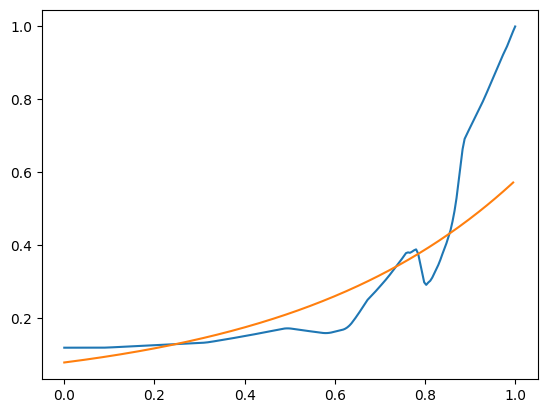

In [29]:
import matplotlib.pyplot as plt

popx = pop_df['Year'].to_list()
popx = [(i-1800)/(max(popx)-1800) for i in popx]
popy = pop_df['Population'].to_list()
popy = [i/max(popy) for i in popy]

scap, ecap = 0, len(popx)
expx = [i / ecap for i in range(scap, ecap)]
expy = [a * np.exp(b * i/ecap) for i in range(scap, ecap)]

plt.plot(popx, popy)
plt.plot(expx, expy)